In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip uninstall -y torchvision uni2ts gluonts

Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128


In [2]:
!pip install -U git+https://github.com/SalesforceAIResearch/uni2ts.git
!pip install -U gluonts

  Cloning https://github.com/SalesforceAIResearch/uni2ts.git to /tmp/pip-req-build-i_jlkzls
  Running command git clone --filter=blob:none --quiet https://github.com/SalesforceAIResearch/uni2ts.git /tmp/pip-req-build-i_jlkzls
  Resolved https://github.com/SalesforceAIResearch/uni2ts.git to commit 7a4e77cff8d6cf480c559c6b6879ee621a492a42
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax[cpu] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax[cpu] to determine which version is compatible with other requirements. This could take

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.5 MB/s eta 0:00:00
  Attempting uninstall: gluonts
    Found existing installation: gluonts 0.14.4
    Uninstalling gluonts-0.14.4:
      Successfully uninstalled gluonts-0.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
uni2ts 2.0.0 requires gluonts~=0.14.3, but you have gluonts 0.16.2 which is incompatible.


In [14]:
from gluonts.dataset.split import split

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

from gluonts.dataset.pandas import PandasDataset
from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATE_COL = "date"
ID_COL = "solar_ref_id"
TARGET_COL = "solar_gen_kwh"

COVARIATE_COLS = [
    "ALLSKY_SFC_SW_DWN",
    "T2M",
    "WS2M",
    "RH2M",
    "day_of_year",
    "month",
]

CONTEXT_START = "2023-01-01"
CONTEXT_END = "2024-12-31"

TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

CONTEXT_START = pd.to_datetime(CONTEXT_START)
CONTEXT_END = pd.to_datetime(CONTEXT_END)

TEST_START = pd.to_datetime(TEST_START)
TEST_END = pd.to_datetime(TEST_END)

CONTEXT_LEN = (CONTEXT_END - CONTEXT_START).days + 1
PRED_LEN = (TEST_END - TEST_START).days + 1

print("CONTEXT_LEN:", CONTEXT_LEN)
print("PRED_LEN:", PRED_LEN)

QUANTILE_LEVELS = [0.1, 0.5, 0.9]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CONTEXT_LEN: 731
PRED_LEN: 365
Device: cuda


# **Prepare benchmark data**

In [4]:
import time
import pandas as pd
import numpy as np

full_data_path = "/content/drive/MyDrive/TT/data/main/daily/main.csv"

full_data = pd.read_csv(full_data_path, parse_dates=["date"])
full_data = full_data.drop(columns=["lat", "long", "T_cell", "temp_factor"])
full_data["date"] = pd.to_datetime(full_data["date"])

full_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
0,AUS_SOLAR_REF_000,2016-01-01,8.9544,31.15,4.20,40.78,42.557171,1,1
1,AUS_SOLAR_REF_000,2016-01-02,8.5466,26.56,4.61,53.99,41.505010,2,1
2,AUS_SOLAR_REF_000,2016-01-03,8.2236,26.15,2.78,55.57,40.121445,3,1
3,AUS_SOLAR_REF_000,2016-01-04,5.6350,25.23,3.16,58.72,28.261850,4,1
4,AUS_SOLAR_REF_000,2016-01-05,5.3940,24.70,3.66,59.91,27.166024,5,1
...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,9.6631,19.30,2.33,41.20,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,8.7079,21.64,3.20,37.60,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,9.6110,24.35,1.99,34.56,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,8.8459,27.43,1.90,27.50,42.693967,364,12


In [5]:
test_data = full_data[full_data['date'] >= "2025-01-01"]
test_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
3288,AUS_SOLAR_REF_000,2025-01-01,6.9077,33.91,2.94,28.34,33.130762,1,1
3289,AUS_SOLAR_REF_000,2025-01-02,8.4636,34.23,3.80,31.01,39.934746,2,1
3290,AUS_SOLAR_REF_000,2025-01-03,8.8351,28.54,5.57,43.08,42.465017,3,1
3291,AUS_SOLAR_REF_000,2025-01-04,9.0682,25.44,5.62,49.62,44.007231,4,1
3292,AUS_SOLAR_REF_000,2025-01-05,9.1289,27.47,4.77,43.23,43.933737,5,1
...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,9.6631,19.30,2.33,41.20,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,8.7079,21.64,3.20,37.60,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,9.6110,24.35,1.99,34.56,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,8.8459,27.43,1.90,27.50,42.693967,364,12


In [6]:
context_data = full_data[(full_data['date'] >= "2023-01-01") & (full_data['date'] <= "2024-12-31")]
context_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
2557,AUS_SOLAR_REF_000,2023-01-01,9.1733,25.61,5.55,45.88,44.443911,1,1
2558,AUS_SOLAR_REF_000,2023-01-02,8.5126,32.21,6.23,25.99,40.464449,2,1
2559,AUS_SOLAR_REF_000,2023-01-03,8.4670,34.70,6.61,17.99,39.875917,3,1
2560,AUS_SOLAR_REF_000,2023-01-04,8.3974,35.58,5.41,15.56,39.438571,4,1
2561,AUS_SOLAR_REF_000,2023-01-05,8.5397,35.16,4.59,17.12,40.117026,5,1
...,...,...,...,...,...,...,...,...,...
1826130,AUS_SOLAR_REF_499,2024-12-27,9.0422,23.97,4.07,39.92,44.137553,362,12
1826131,AUS_SOLAR_REF_499,2024-12-28,8.9806,20.70,2.78,38.84,44.405118,363,12
1826132,AUS_SOLAR_REF_499,2024-12-29,9.2892,22.96,2.24,45.36,45.410609,364,12
1826133,AUS_SOLAR_REF_499,2024-12-30,8.7276,25.67,1.64,40.74,42.454566,365,12


In [7]:
print("context_data:", context_data.shape)
print("test_data:", test_data.shape)

context_data: (365500, 9)
test_data: (182500, 9)


In [8]:
def prepare_df(df):
    df = df.copy()

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df[ID_COL] = df[ID_COL].astype(str)

    numeric_cols = [TARGET_COL] + COVARIATE_COLS

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

    return df


def filter_by_date_range(context_data, test_data):
    context_data = context_data[
        (context_data[DATE_COL] >= CONTEXT_START) &
        (context_data[DATE_COL] <= CONTEXT_END)
    ].copy()

    test_data = test_data[
        (test_data[DATE_COL] >= TEST_START) &
        (test_data[DATE_COL] <= TEST_END)
    ].copy()

    ctx_count = context_data.groupby(ID_COL)[DATE_COL].nunique()
    test_count = test_data.groupby(ID_COL)[DATE_COL].nunique()

    coverage = pd.DataFrame({
        "context_days": ctx_count,
        "test_days": test_count,
    }).fillna(0).astype(int)

    coverage["valid"] = (
        (coverage["context_days"] == CONTEXT_LEN) &
        (coverage["test_days"] == PRED_LEN)
    )

    valid_ids = coverage[coverage["valid"]].index.tolist()

    context_data = context_data[context_data[ID_COL].isin(valid_ids)].copy()
    test_data = test_data[test_data[ID_COL].isin(valid_ids)].copy()

    return context_data, test_data, coverage, valid_ids

context_data = prepare_df(context_data)
test_data = prepare_df(test_data)

context_data, test_data, coverage, valid_ids = filter_by_date_range(
    context_data,
    test_data,
)

print("CONTEXT_LEN:", CONTEXT_LEN)
print("PRED_LEN:", PRED_LEN)
print("context_data:", context_data.shape)
print("test_data:", test_data.shape)
print("valid series:", len(valid_ids))

display(coverage.head(20))

CONTEXT_LEN: 731
PRED_LEN: 365
context_data: (365500, 9)
test_data: (182500, 9)
valid series: 500


,context_days,test_days,valid
solar_ref_id,,,
AUS_SOLAR_REF_000,731,365,True
AUS_SOLAR_REF_001,731,365,True
AUS_SOLAR_REF_002,731,365,True
AUS_SOLAR_REF_003,731,365,True
AUS_SOLAR_REF_004,731,365,True
AUS_SOLAR_REF_005,731,365,True
AUS_SOLAR_REF_006,731,365,True
AUS_SOLAR_REF_007,731,365,True
AUS_SOLAR_REF_008,731,365,True


In [9]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    ) * 100


def quantile_loss(y_true, y_pred_q, q):
    y_true = np.asarray(y_true, dtype=float)
    y_pred_q = np.asarray(y_pred_q, dtype=float)

    error = y_true - y_pred_q
    return np.mean(np.maximum(q * error, (q - 1) * error))


def evaluate_forecast(pred_df, test_df, model_name, benchmark_name):
    pred_df = pred_df.copy()
    test_df = test_df.copy()

    pred_df[DATE_COL] = pd.to_datetime(pred_df[DATE_COL])
    test_df[DATE_COL] = pd.to_datetime(test_df[DATE_COL])

    pred_df[ID_COL] = pred_df[ID_COL].astype(str)
    test_df[ID_COL] = test_df[ID_COL].astype(str)

    # Quan trọng: merge nguyên pred_df để giữ q0.1, q0.5, q0.9 nếu có
    merged = test_df[[ID_COL, DATE_COL, TARGET_COL]].merge(
        pred_df,
        on=[ID_COL, DATE_COL],
        how="inner",
    )

    if len(merged) == 0:
        raise ValueError(
            f"Không match được dòng nào cho {model_name} - {benchmark_name}"
        )

    y_true = merged[TARGET_COL].to_numpy()
    y_pred = merged["y_pred"].to_numpy()

    mse = mean_squared_error(y_true, y_pred)

    metrics = {
        "model": model_name,
        "benchmark": benchmark_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "sMAPE": smape(y_true, y_pred),
        "n_points": len(merged),
        "n_series": merged[ID_COL].nunique(),
    }

    if "q0.1" in merged.columns:
        metrics["QL_0.1"] = quantile_loss(
            y_true,
            merged["q0.1"].to_numpy(),
            0.1,
        )

    if "q0.5" in merged.columns:
        metrics["QL_0.5"] = quantile_loss(
            y_true,
            merged["q0.5"].to_numpy(),
            0.5,
        )

    if "q0.9" in merged.columns:
        metrics["QL_0.9"] = quantile_loss(
            y_true,
            merged["q0.9"].to_numpy(),
            0.9,
        )

    return metrics, merged

# **Load model and predict**

In [16]:
model = Moirai2Forecast(
    module=Moirai2Module.from_pretrained("Salesforce/moirai-2.0-R-small"),
    prediction_length=PRED_LEN,
    context_length=CONTEXT_LEN,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

model = model.to(DEVICE)
model.eval()

print("Moirai 2.0 R-small loaded on", DEVICE)
print("Quantile levels:", model.module.quantile_levels)

Moirai 2.0 R-small loaded on cuda
Quantile levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [17]:
def get_moirai_forecast_values(forecast, n):
    if hasattr(forecast, "quantile"):
        y_pred = np.asarray(forecast.quantile(0.5))[:n]
        q01 = np.asarray(forecast.quantile(0.1))[:n]
        q09 = np.asarray(forecast.quantile(0.9))[:n]

        return {
            "y_pred": y_pred,
            "q0.1": q01,
            "q0.5": y_pred,
            "q0.9": q09,
        }

    y_pred = np.asarray(forecast.mean)[:n]

    return {
        "y_pred": y_pred,
    }

In [18]:
def extract_moirai2_quantiles(pred_arr, n):
    """
    pred_arr từ model.predict() thường có shape:
    batch x num_quantiles x prediction_length

    Hàm này lấy q0.1, q0.5, q0.9 và y_pred = q0.5.
    """

    pred_arr = np.asarray(pred_arr)

    # Lấy batch đầu tiên
    pred_arr = pred_arr[0]

    # Nếu còn target_dim ở cuối thì bỏ target_dim
    if pred_arr.ndim == 3:
        pred_arr = pred_arr[:, :, 0]

    quantile_levels = np.asarray(model.module.quantile_levels, dtype=float)

    def get_q(q):
        idx = int(np.argmin(np.abs(quantile_levels - q)))
        return pred_arr[idx, :n]

    q01 = get_q(0.1)
    q05 = get_q(0.5)
    q09 = get_q(0.9)

    return {
        "y_pred": q05,
        "q0.1": q01,
        "q0.5": q05,
        "q0.9": q09,
    }

In [19]:
# target only
def run_moirai2_target_only(context_data, test_data):
    start = time.time()
    all_preds = []

    for sid, g_ctx in context_data.groupby(ID_COL):
        g_ctx = g_ctx.sort_values(DATE_COL).copy()

        g_test = (
            test_data[test_data[ID_COL] == sid]
            .sort_values(DATE_COL)
            .copy()
        )

        if len(g_ctx) != CONTEXT_LEN or len(g_test) != PRED_LEN:
            continue

        context = g_ctx[TARGET_COL].astype(float).to_numpy()

        if np.isnan(context).any():
            continue

        with torch.no_grad():
            pred_arr = model.predict(
                past_target=[context],
            )

        pred_values = extract_moirai2_quantiles(
            pred_arr,
            n=len(g_test),
        )

        tmp = pd.DataFrame({
            ID_COL: sid,
            DATE_COL: g_test[DATE_COL].to_numpy(),
            "y_pred": pred_values["y_pred"],
            "q0.1": pred_values["q0.1"],
            "q0.5": pred_values["q0.5"],
            "q0.9": pred_values["q0.9"],
        })

        all_preds.append(tmp)

    if len(all_preds) == 0:
        raise ValueError(
            "Moirai target-only không tạo được prediction nào. "
            "Hãy kiểm tra CONTEXT_LEN, PRED_LEN, date range hoặc missing values."
        )

    pred_df = pd.concat(all_preds, ignore_index=True)
    runtime = time.time() - start

    return pred_df, runtime

moirai_target_pred, moirai_target_runtime = run_moirai2_target_only(
    context_data,
    test_data,
)

moirai_target_metrics, moirai_target_merged = evaluate_forecast(
    pred_df=moirai_target_pred,
    test_df=test_data,
    model_name="Moirai-2.0-R-small",
    benchmark_name="target_only",
)

moirai_target_metrics["runtime_seconds"] = moirai_target_runtime

display(moirai_target_pred.head())
moirai_target_metrics

,solar_ref_id,date,y_pred,q0.1,q0.5,q0.9
0,AUS_SOLAR_REF_000,2025-01-01,37.971764,29.124624,37.971764,43.415989
1,AUS_SOLAR_REF_000,2025-01-02,40.852600,31.101376,40.852600,44.636829
2,AUS_SOLAR_REF_000,2025-01-03,42.670387,32.929157,42.670387,45.105225
3,AUS_SOLAR_REF_000,2025-01-04,43.247341,33.478348,43.247341,45.068581
4,AUS_SOLAR_REF_000,2025-01-05,43.338970,33.590054,43.338970,44.946434


{'model': 'Moirai-2.0-R-small',
 'benchmark': 'target_only',
 'MAE': 5.212430299902582,
 'MSE': 47.046368236879516,
 'RMSE': 6.859035517977693,
 'MAPE': 25.41240744694095,
 'sMAPE': 21.876668353405197,
 'n_points': 182500,
 'n_series': 500,
 'QL_0.1': 1.4268521087256192,
 'QL_0.5': 2.606215149951291,
 'QL_0.9': 1.2757076555055897,
 'runtime_seconds': 61.246031284332275}

In [21]:
# target + covariates
def run_moirai2_target_future_covariates(context_data, test_data):
    """
    Kịch bản target + future covariates cho Moirai.

    Cách làm:
    1. Ridge học solar_gen_kwh từ covariates quá khứ.
    2. Tính residual = solar_gen_kwh - Ridge prediction.
    3. Moirai dự báo residual tương lai bằng model.predict().
    4. Final forecast = Ridge(covariates tương lai) + Moirai(residual tương lai).
    """

    start = time.time()
    all_preds = []

    for sid, g_ctx in context_data.groupby(ID_COL):
        g_ctx = g_ctx.sort_values(DATE_COL).copy()

        g_test = (
            test_data[test_data[ID_COL] == sid]
            .sort_values(DATE_COL)
            .copy()
        )

        if len(g_ctx) != CONTEXT_LEN or len(g_test) != PRED_LEN:
            continue

        train_df = g_ctx.dropna(
            subset=[TARGET_COL] + COVARIATE_COLS
        ).copy()

        future_df = g_test.dropna(
            subset=COVARIATE_COLS
        ).copy()

        if len(train_df) != CONTEXT_LEN or len(future_df) != PRED_LEN:
            continue

        # 1. Ridge học phần target được giải thích bởi covariates
        xreg = make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0),
        )

        xreg.fit(
            train_df[COVARIATE_COLS].to_numpy(),
            train_df[TARGET_COL].to_numpy(),
        )

        train_df["xreg_pred"] = xreg.predict(
            train_df[COVARIATE_COLS].to_numpy()
        )

        train_df["residual"] = (
            train_df[TARGET_COL] - train_df["xreg_pred"]
        )

        future_df["xreg_pred"] = xreg.predict(
            future_df[COVARIATE_COLS].to_numpy()
        )

        # 2. Dùng Moirai dự báo residual bằng model.predict()
        residual_context = train_df["residual"].astype(float).to_numpy()

        if np.isnan(residual_context).any():
            continue

        with torch.no_grad():
            residual_pred_arr = model.predict(
                past_target=[residual_context],
            )

        residual_values = extract_moirai2_quantiles(
            residual_pred_arr,
            n=len(future_df),
        )

        xreg_future = future_df["xreg_pred"].to_numpy()

        # 3. Final forecast = xreg future + residual forecast
        y_pred = xreg_future + residual_values["y_pred"]

        tmp = pd.DataFrame({
            ID_COL: sid,
            DATE_COL: future_df[DATE_COL].to_numpy(),
            "y_pred": y_pred,
            "q0.1": xreg_future + residual_values["q0.1"],
            "q0.5": y_pred,
            "q0.9": xreg_future + residual_values["q0.9"],
        })

        all_preds.append(tmp)

    if len(all_preds) == 0:
        raise ValueError(
            "Moirai target + future covariates không tạo được prediction nào. "
            "Hãy kiểm tra missing values trong covariates, CONTEXT_LEN/PRED_LEN hoặc date range."
        )

    pred_df = pd.concat(all_preds, ignore_index=True)
    runtime = time.time() - start

    return pred_df, runtime

moirai_cov_pred, moirai_cov_runtime = run_moirai2_target_future_covariates(
    context_data,
    test_data,
)

moirai_cov_metrics, moirai_cov_merged = evaluate_forecast(
    pred_df=moirai_cov_pred,
    test_df=test_data,
    model_name="Moirai-2.0-R-small",
    benchmark_name="target_future_covariates_xreg_residual",
)

moirai_cov_metrics["runtime_seconds"] = moirai_cov_runtime

display(moirai_cov_pred.head())
moirai_cov_metrics

,solar_ref_id,date,y_pred,q0.1,q0.5,q0.9
0,AUS_SOLAR_REF_000,2025-01-01,33.072261,32.644569,33.072261,33.318311
1,AUS_SOLAR_REF_000,2025-01-02,40.346896,39.882494,40.346896,40.621148
2,AUS_SOLAR_REF_000,2025-01-03,42.650916,42.196961,42.650916,42.956714
3,AUS_SOLAR_REF_000,2025-01-04,44.062181,43.625992,44.062181,44.383882
4,AUS_SOLAR_REF_000,2025-01-05,44.116830,43.701864,44.116830,44.446705


{'model': 'Moirai-2.0-R-small',
 'benchmark': 'target_future_covariates_xreg_residual',
 'MAE': 0.2558957632497489,
 'MSE': 0.12338155615202068,
 'RMSE': 0.35125710832952645,
 'MAPE': 1.3997813840843734,
 'sMAPE': 1.3573003497511738,
 'n_points': 182500,
 'n_series': 500,
 'QL_0.1': 0.09460171015446427,
 'QL_0.5': 0.12794788162487444,
 'QL_0.9': 0.04756713310870612,
 'runtime_seconds': 65.97945642471313}

# **Benchmark**

In [22]:
moirai_target_pred.to_csv("/content/drive/MyDrive/TT/benchmark_results/moirai_target_only_pred.csv", index=False)
moirai_cov_pred.to_csv("/content/drive/MyDrive/TT/benchmark_results/moirai_future_cov_pred.csv", index=False)

moirai_metrics = pd.DataFrame([
    moirai_target_metrics,
    moirai_cov_metrics,
])

display(moirai_metrics)

moirai_metrics.to_csv("/content/drive/MyDrive/TT/benchmark_results/moirai_metrics.csv", index=False)

print("Saved:")
print("- moirai_target_only_pred.csv")
print("- moirai_future_cov_pred.csv")
print("- moirai_metrics.csv")

,model,benchmark,MAE,MSE,RMSE,MAPE,sMAPE,n_points,n_series,QL_0.1,QL_0.5,QL_0.9,runtime_seconds
0,Moirai-2.0-R-small,target_only,5.212430,47.046368,6.859036,25.412407,21.876668,182500,500,1.426852,2.606215,1.275708,61.246031
1,Moirai-2.0-R-small,target_future_covariates_xreg_residual,0.255896,0.123382,0.351257,1.399781,1.357300,182500,500,0.094602,0.127948,0.047567,65.979456


Saved:
- moirai_target_only_pred.csv
- moirai_future_cov_pred.csv
- moirai_metrics.csv


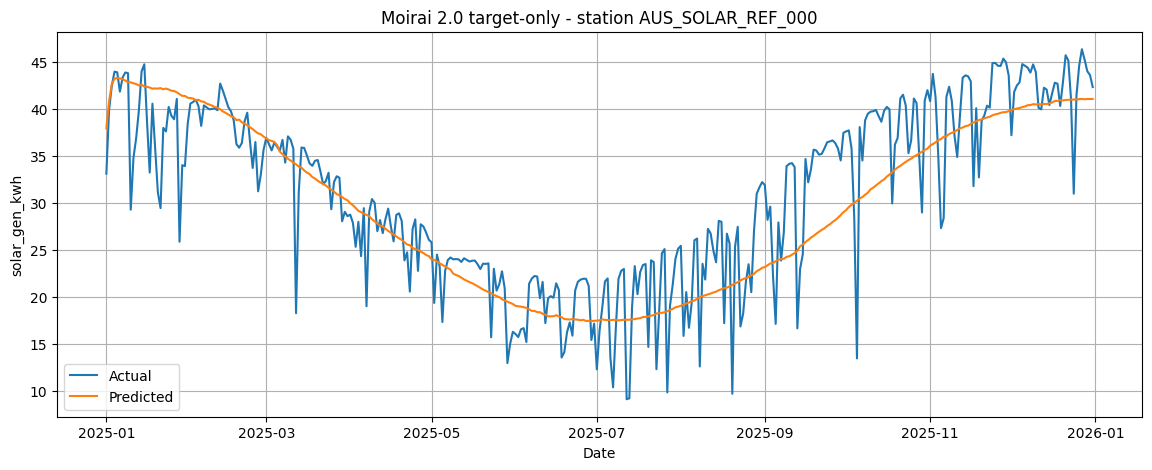

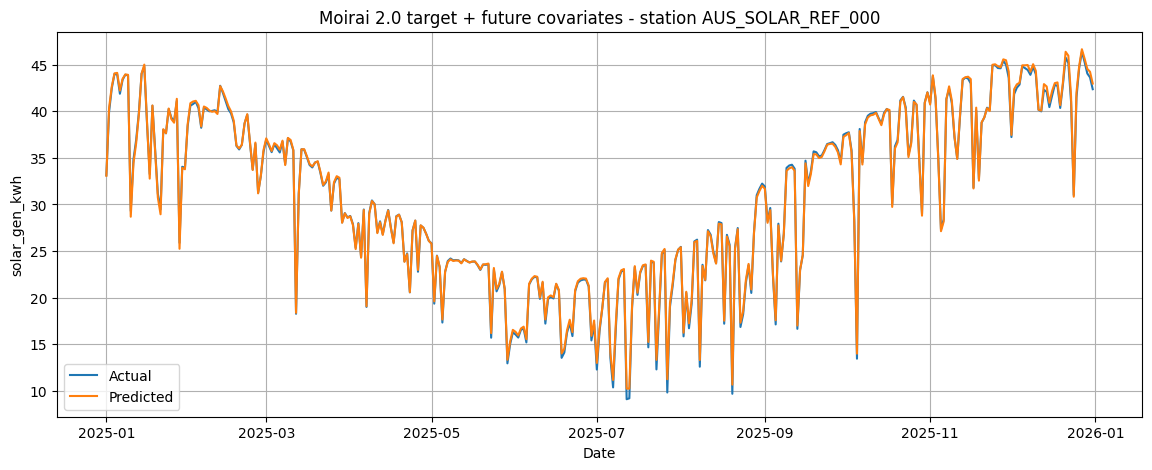

In [23]:
import matplotlib.pyplot as plt

def plot_forecast_for_station(pred_df, test_df, station_id, title):
    station_id = str(station_id)

    pred_g = pred_df[pred_df[ID_COL] == station_id].sort_values(DATE_COL)
    test_g = test_df[test_df[ID_COL] == station_id].sort_values(DATE_COL)

    merged = test_g[[DATE_COL, TARGET_COL]].merge(
        pred_g[[DATE_COL, "y_pred"]],
        on=DATE_COL,
        how="inner",
    )

    plt.figure(figsize=(14, 5))
    plt.plot(merged[DATE_COL], merged[TARGET_COL], label="Actual")
    plt.plot(merged[DATE_COL], merged["y_pred"], label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.show()


sample_station = valid_ids[0]

plot_forecast_for_station(
    pred_df=moirai_target_pred,
    test_df=test_data,
    station_id=sample_station,
    title=f"Moirai 2.0 target-only - station {sample_station}",
)

plot_forecast_for_station(
    pred_df=moirai_cov_pred,
    test_df=test_data,
    station_id=sample_station,
    title=f"Moirai 2.0 target + future covariates - station {sample_station}",
)